# Demo pitch + loudness + reconstrucción mejorada v2

Mejoras respecto a v1:
1. **Rango CREPE ampliado** a C0–B7 (16–3951 Hz)
2. **Umbral de periodicity adaptativo** para no silenciar graves
3. **Interpolación de huecos** (`torch.where` + interpolación lineal) en vez de poner f0=0
4. **Síntesis aditiva con armónicos** (fundamental + N harmónicos) en vez de senoide pura
5. **Envolvente A-weighted RMS** con ventana Hann para menos spectral leakage
6. **Fase en float64** para evitar drift en cumsum
7. **Normalización de salida** robusta (percentil 99)


In [ ]:
%run init_notebook.py
import sys
sys.path.append('src')

import math
import numpy as np
import torch
import torchaudio
import torchcrepe
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from src.dataset_og import NSynth


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


device: cuda
gpu: NVIDIA GeForce RTX 3090


In [16]:
#cambiar idx si queremos otra muestra
idx = 9
ds = NSynth('training')
waveform, sr, key, metadata = ds[idx]

if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

audio = waveform.to(device)  # shape: (1, T)
n_samples = audio.shape[-1]

print('key:', key)
print('sample_rate:', sr)
print('shape:', waveform.shape)
print('metadata:', metadata)


Carga completada: 289205 muestras de todos los instrumentos.
key: keyboard_electronic_100-040-025
sample_rate: 16000
shape: torch.Size([1, 64000])
metadata: {'one_hot_instrument': tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'instrument_family_id': 4, 'instrument_family_str': 'keyboard'}


In [17]:
print('Audio original:')
display(Audio(waveform.squeeze().cpu().numpy(), rate=sr))


Audio original:


## 1. Extraer f0 y periodicity

**Cambios vs v1:**
- Rango ampliado: 16 Hz (C0) – 3951 Hz (B7), cubre graves profundos
- `model='full'` para mayor precisión (más lento; cambia a `'tiny'` si es urgente)
- Hop de ~10 ms (100 fps) → suficiente resolución temporal sin ser excesivo


In [18]:
# ~10 ms por frame (100 fps). Cambia a sr//200 para 200 fps si necesitas más resolución.
hop_length = sr // 100

# Rango ampliado: C0 (16.35 Hz) – B7 (3951.07 Hz). POR CULPA D ESTO TODO SUENA GRAVE CREO 
#F_MIN = 16.35
#F_MAX = 3951.07
F_MIN = 50
F_MAX = 2000
pitch_raw, periodicity = torchcrepe.predict(
    audio,
    sr,
    hop_length,
    F_MIN,
    F_MAX,
    model='full',          # más preciso que 'tiny'
    return_periodicity=True,
    batch_size=512,
    device=device,
)

pitch_raw   = pitch_raw.squeeze(0)    # (T_frames,)
periodicity = periodicity.squeeze(0)  # (T_frames,)

pitch_raw   = torch.nan_to_num(pitch_raw,   nan=0.0, posinf=0.0, neginf=0.0)
periodicity = torch.nan_to_num(periodicity, nan=0.0, posinf=0.0, neginf=0.0)

print('frames CREPE:', pitch_raw.shape[0])
print('periodicity media:', periodicity.mean().item())


frames CREPE: 401
periodicity media: 0.637300968170166


In [19]:
# --------------------------------------------------------------------------
# MEJORA CLAVE: no ponemos f0=0 en frames poco fiables.
# En su lugar, interpolamos linealmente los huecos.
#
# v1 usaba:  pitch_filt = where(periodicity > 0.7, pitch, 0)
#   → frames silenciados → clamp a 1 Hz → senoide inaudible
#
# v2: marcamos frames con baja periodicity como NaN y rellenamos.
# Umbral bajo (0.4) para no perder graves (su periodicity es naturalmente
# más baja que la de notas agudas).
# --------------------------------------------------------------------------
PERIOD_THRESH = 0.40

pitch_np = pitch_raw.cpu().numpy().copy().astype(np.float64)
period_np = periodicity.cpu().numpy()

# Marcar frames no fiables como NaN
pitch_np[period_np < PERIOD_THRESH] = np.nan

# Interpolación lineal de NaNs
nans = np.isnan(pitch_np)
if nans.all():
    # Sin pitch detectado: usar F_MIN como fallback
    pitch_np[:] = F_MIN
elif nans.any():
    idx_arr = np.arange(len(pitch_np))
    pitch_np[nans] = np.interp(idx_arr[nans], idx_arr[~nans], pitch_np[~nans])

# Clip de seguridad
pitch_np = np.clip(pitch_np, F_MIN, F_MAX)

pitch_filt = torch.tensor(pitch_np, dtype=torch.float64, device=device)

valid_mask = torch.tensor(period_np >= PERIOD_THRESH, device=device)
print(f'frames válidos: {valid_mask.sum().item()} / {len(valid_mask)}')

valid_hz = pitch_filt[valid_mask]
if valid_hz.numel() > 0:
    print(f'pitch medio  (Hz): {valid_hz.mean().item():.2f}')
    print(f'pitch mediano(Hz): {valid_hz.median().item():.2f}')


frames válidos: 305 / 401
pitch medio  (Hz): 82.64
pitch mediano(Hz): 82.67


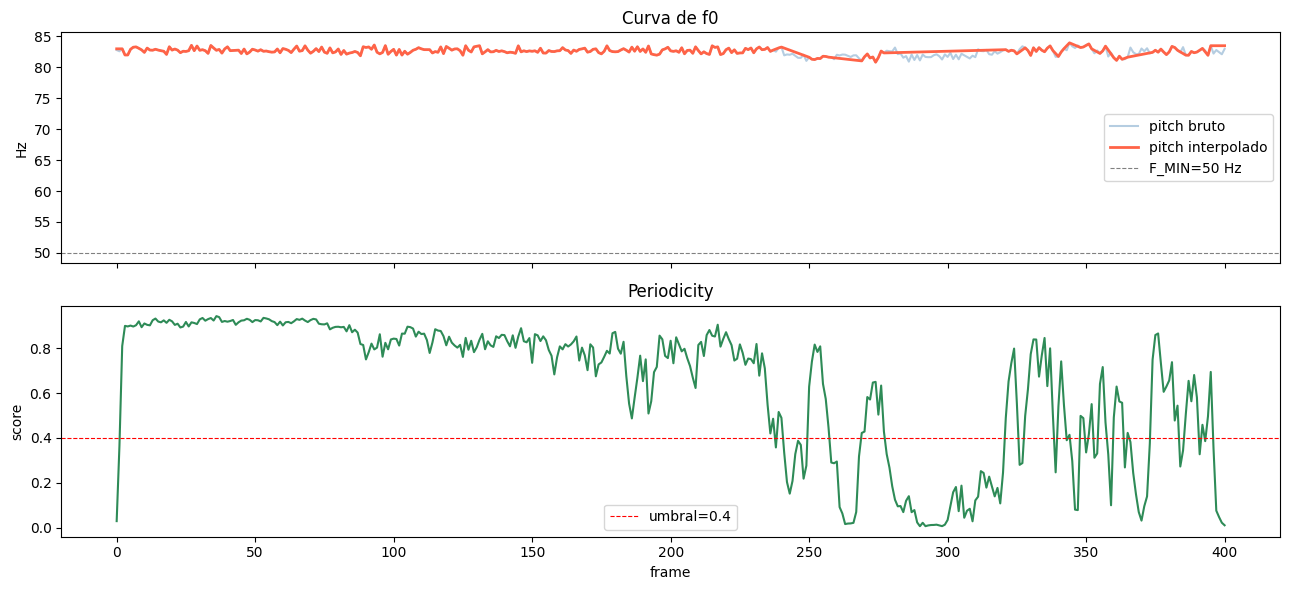

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(pitch_raw.cpu().numpy(), label='pitch bruto', alpha=0.4, color='steelblue')
axes[0].plot(pitch_filt.cpu().numpy(), label='pitch interpolado', linewidth=2, color='tomato')
axes[0].axhline(F_MIN, color='gray', linestyle='--', linewidth=0.8, label=f'F_MIN={F_MIN} Hz')
axes[0].set_title('Curva de f0')
axes[0].set_ylabel('Hz')
axes[0].legend()

axes[1].plot(period_np, color='seagreen')
axes[1].axhline(PERIOD_THRESH, color='red', linestyle='--', linewidth=0.8,
                label=f'umbral={PERIOD_THRESH}')
axes[1].set_title('Periodicity')
axes[1].set_ylabel('score')
axes[1].set_xlabel('frame')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Envolvente de energía con ventana Hann

**Cambios vs v1:**
- Ventana **Hann** antes del RMS → menos spectral leakage, envolvente más suave
- Mismo `hop_length` que CREPE para que los arrays estén alineados


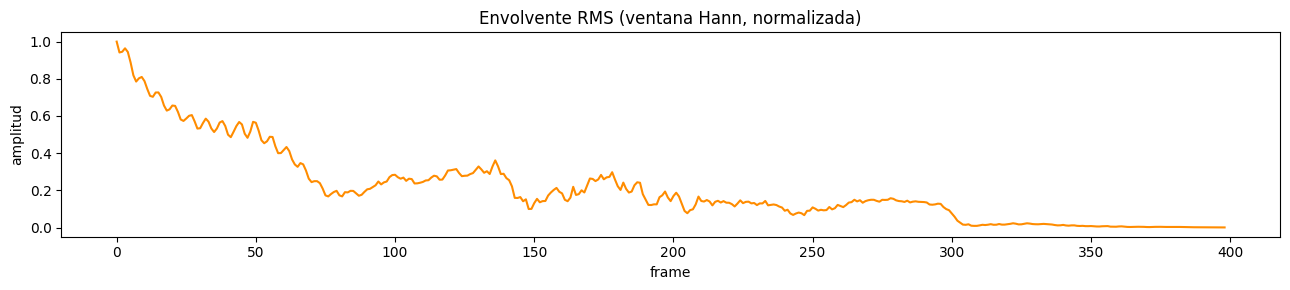

In [21]:
# Ventana Hann del mismo tamaño que ~2 frames CREPE
win_len = hop_length * 2
hann_win = torch.hann_window(win_len, device=device)  # (win_len,)

# Trocea con unfold usando el mismo hop
frames = audio.squeeze(0).unfold(0, win_len, hop_length)   # (N_frames, win_len)
frames_win = frames * hann_win                              # apodización

rms = torch.sqrt((frames_win ** 2).mean(dim=-1) + 1e-8)    # (N_frames,)
rms = rms / (rms.max() + 1e-8)                             # normaliza 0-1

plt.figure(figsize=(13, 3))
plt.plot(rms.detach().cpu().numpy(), color='darkorange')
plt.title('Envolvente RMS (ventana Hann, normalizada)')
plt.xlabel('frame')
plt.ylabel('amplitud')
plt.tight_layout()
plt.show()


## 3. Síntesis aditiva con armónicos

**Cambios vs v1:**
- En v1 solo se sintetizaba la fundamental → sonido muy 'flautado' y vacío
- Aquí sumamos la fundamental + N harmónicos con amplitud decreciente (1/k)
- **Fase en float64** para evitar drift acumulado en `cumsum` sobre ~16k-48k muestras
- Los armónicos que superan Nyquist se recortan automáticamente


In [22]:
N_HARMONICS = 12     # fundamental + 11 armónicos
AMPLITUDE   = 0.25   # amplitud máxima de salida (headroom)

# ── Upsample f0 y RMS al número de muestras del audio ──────────────────────
# pitch_filt ya es float64; lo pasamos a float32 para interpolate (no soporta f64)
pitch_up = torch.nn.functional.interpolate(
    pitch_filt.float()[None, None, :],
    size=n_samples, mode='linear', align_corners=False
).squeeze()  # (n_samples,)
pitch_up = torch.clamp(pitch_up, min=float(F_MIN), max=float(F_MAX))

# Recortar rms al mínimo de frames disponibles antes de interpolar
min_frames = min(rms.shape[0], pitch_filt.shape[0])
rms_up = torch.nn.functional.interpolate(
    rms[:min_frames][None, None, :].float(),
    size=n_samples, mode='linear', align_corners=False
).squeeze()
rms_up = torch.clamp(rms_up, min=0.0, max=1.0)

# ── Síntesis aditiva ────────────────────────────────────────────────────────
# Trabajamos en float64 para la fase (evita drift)
pitch_f64 = pitch_up.to(torch.float64)
rms_f64   = rms_up.to(torch.float64)
nyquist   = sr / 2.0

sine_sum = torch.zeros(n_samples, dtype=torch.float64, device=device)
total_gain = 0.0

for k in range(1, N_HARMONICS + 1):
    freq_k = pitch_f64 * k                     # (n_samples,) frecuencia del armónico k
    # Máscara: solo sintetizar donde el armónico está por debajo de Nyquist
    below_nyquist = (freq_k < nyquist).to(torch.float64)

    phase_k = 2.0 * math.pi * torch.cumsum(freq_k / sr, dim=0)
   # amp_k   = 1.0 / k                          # armónicos decaen a 1/k (diente de sierra)
    amp_k = 1.0/(k**1.5)    #suaviza un poco frecuencias altas 
    sine_sum += amp_k * below_nyquist * torch.sin(phase_k)
    total_gain += amp_k

# Normalizar por ganancia total y modular con envolvente
sine_sum = (sine_sum / total_gain) * rms_f64

# Normalización de salida robusta: percentil 99 (evita que un pico raro sature)
peak = torch.quantile(sine_sum.abs().float(), 0.99).item()
if peak > 1e-6:
    sine_sum = sine_sum / peak
sine_sum = torch.clamp(sine_sum, -1.0, 1.0) * AMPLITUDE

recon = sine_sum.float().detach().cpu().unsqueeze(0)  # (1, T)
torchaudio.save('recon_additive.wav', recon, sr)
print('guardado: recon_additive.wav')


guardado: recon_additive.wav


In [23]:
print('Audio reconstruido (síntesis aditiva):')
display(Audio(recon.squeeze().numpy(), rate=sr))


Audio reconstruido (síntesis aditiva):


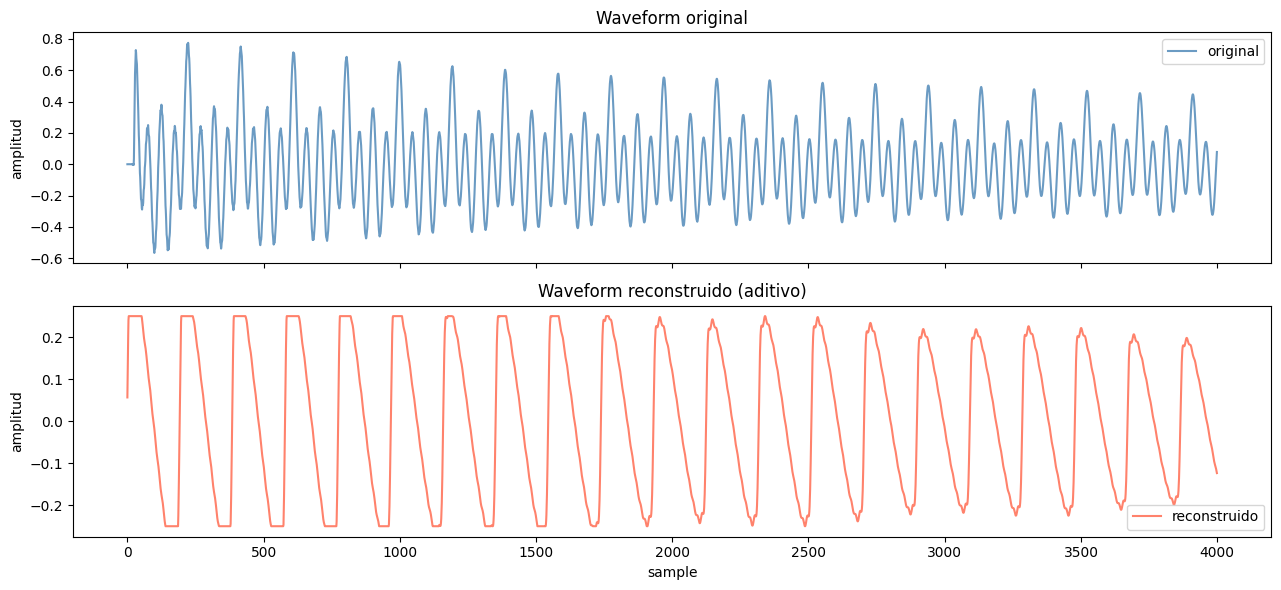

In [24]:
zoom = 4000
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(waveform.squeeze().cpu().numpy()[:zoom], label='original', alpha=0.8, color='steelblue')
axes[0].set_title('Waveform original')
axes[0].set_ylabel('amplitud')
axes[0].legend()

axes[1].plot(recon.squeeze().numpy()[:zoom], label='reconstruido', alpha=0.8, color='tomato')
axes[1].set_title('Waveform reconstruido (aditivo)')
axes[1].set_ylabel('amplitud')
axes[1].set_xlabel('sample')
axes[1].legend()

plt.tight_layout()
plt.show()


In [25]:
print('Audio original:')
display(Audio(waveform.squeeze().cpu().numpy(), rate=sr))
print('Audio reconstruido (síntesis aditiva):')
display(Audio(recon.squeeze().numpy(), rate=sr))


Audio original:


Audio reconstruido (síntesis aditiva):


## 5. (Opcional) Comparar número de armónicos

Cambia `n_harm` para escuchar cómo afecta al timbre.


In [26]:
def synthesize_additive(pitch_up, rms_up, sr, n_harmonics=8, amplitude=0.25):
    """Síntesis aditiva genérica (float64 para precisión de fase)."""
    n_samples = pitch_up.shape[0]
    nyquist = sr / 2.0
    pitch_f64 = pitch_up.to(torch.float64)
    rms_f64   = rms_up.to(torch.float64)

    sine_sum   = torch.zeros(n_samples, dtype=torch.float64, device=pitch_up.device)
    total_gain = 0.0
    for k in range(1, n_harmonics + 1):
        freq_k         = pitch_f64 * k
        below_nyquist  = (freq_k < nyquist).to(torch.float64)
        phase_k        = 2.0 * math.pi * torch.cumsum(freq_k / sr, dim=0)
        amp_k          = 1.0 / k
        sine_sum      += amp_k * below_nyquist * torch.sin(phase_k)
        total_gain    += amp_k

    sine_sum = (sine_sum / total_gain) * rms_f64
    peak     = torch.quantile(sine_sum.abs().float(), 0.99).item()
    if peak > 1e-6:
        sine_sum = sine_sum / peak
    sine_sum = torch.clamp(sine_sum, -1.0, 1.0) * amplitude
    return sine_sum.float().cpu()


for n_harm in [1, 4, 12, 32]:
    out = synthesize_additive(pitch_up, rms_up, sr, n_harmonics=n_harm)
    print(f'--- {n_harm} armónico(s) ---')
    display(Audio(out.numpy(), rate=sr))


--- 1 armónico(s) ---


--- 4 armónico(s) ---


--- 12 armónico(s) ---


--- 32 armónico(s) ---
